# Maze Solver - Solution Validation Analysis

This notebook validates whether LLM-generated solutions are actually correct,
not just exact matches to the training solutions.

**Key Questions:**
1. How many predictions match exactly?
2. How many predictions are valid alternative solutions?
3. What types of errors does the model make?
4. Is the model truly overfitting or just being creative?

In [49]:
import sys
import json
import torch
from datetime import datetime
import numpy as np
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# Add src to path
sys.path.append('./src')

if 'solution_validator' in sys.modules:
    del sys.modules['solution_validator']

# Import our modules
from model import ResNetGPT2PrefixModel
from tokenizer import SimpleTokenizer
from dataset import MazeDataset, collate_fn
from solution_validator import validate_solution, evaluate_with_validation, print_evaluation_results
from data_utils import load_maze_dataset, print_dataset_info

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Trained Model

In [50]:
# Load checkpoint
checkpoint = torch.load('models/resnet_gpt2_prefix.pth', map_location=device)

# Initialize tokenizer
tokenizer = SimpleTokenizer()

# Initialize model with EXACT config from training
model = ResNetGPT2PrefixModel(
    vocab_size=checkpoint['vocab_size'],
    gpt2_hidden_size=128,  # Your model used 64-dim
    num_layers=2,
    num_attention_heads=2,
    num_prefix_tokens=checkpoint['num_prefix_tokens'],
    dropout=0.4
)

model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print(f"✓ Model loaded successfully")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

C:\Users\seena\AppData\Local\Temp\ipykernel_4684\2024777241.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('models/resnet_gpt2_prefix.pth', map_

✓ Model loaded successfully
Parameters: 11,952,320


## 2. Load Test Data & Create Maze Grid Lookup

In [51]:
# Load test data with new structure
with open('data/test_sequences.json', 'r') as f:
    test_data = json.load(f)
    test_entries = test_data['entries']  # Extract entries
    test_metadata = test_data['metadata']  # Extract metadata

print(f"Loaded {len(test_entries)} test mazes")
print(f"Grid size: {test_metadata['grid_size']}×{test_metadata['grid_size']}")
print(f"Start: {test_metadata['start_position']}, Goal: {test_metadata['goal_position']}")

Loaded 1400 test mazes
Grid size: 5×5
Start: [0, 4], Goal: [4, 0]


In [52]:
def load_maze_grid(image_path, grid_rows=7, grid_cols=7):
    """
    Convert maze image to binary grid (0=path, 1=wall).
    
    Handles colored start (green) and goal (blue) squares.
    """
    # Load as RGB to detect colors
    img_rgb = Image.open(image_path).convert('RGB')
    img_array_rgb = np.array(img_rgb)
    
    # Also load grayscale for regular cells
    img_gray = Image.open(image_path).convert('L')
    img_array_gray = np.array(img_gray)
    
    height, width = img_array_gray.shape
    cell_height = height // grid_rows
    cell_width = width // grid_cols
    
    grid = np.zeros((grid_rows, grid_cols), dtype=int)
    
    for row in range(grid_rows):
        for col in range(grid_cols):
            # Sample from center of cell
            center_y = row * cell_height + cell_height // 2
            center_x = col * cell_width + cell_width // 2
            
            # Get RGB values
            r, g, b = img_array_rgb[center_y, center_x]
            
            # Check if it's green (start) or blue (goal) - treat as path
            is_green = (g > 100 and g > r and g > b)  # Green dominant
            is_blue = (b > 100 and b > r and b > g)   # Blue dominant
            
            if is_green or is_blue:
                # Colored squares are paths
                grid[row, col] = 0
            else:
                # Use grayscale for regular cells
                pixel_value = img_array_gray[center_y, center_x]
                grid[row, col] = 1 if pixel_value < 127 else 0
    
    return grid



# Load test data with metadata
test_entries, metadata = load_maze_dataset('data/test_sequences.json')

# Print dataset info
print_dataset_info(metadata, len(test_entries), dataset_name="Test")

# Extract grid size from metadata
GRID_SIZE = metadata['grid_size']
ROWS = metadata['rows']
COLS = metadata['cols']

print(f"✓ Using grid size: {ROWS}×{COLS}")
# # Reload grids with the fixed function
# GRID_SIZE = 7

maze_grids = {}
for entry in test_entries:
    maze_id = entry['id']
    img_path = entry['image']
    maze_grids[maze_id] = load_maze_grid(img_path, grid_rows=GRID_SIZE, grid_cols=GRID_SIZE)

print(f"✓ Reloaded {len(maze_grids)} maze grids with color handling")

# Verify maze 2 now
sample_grid = maze_grids[test_entries[2]['id']]
print(f"\nMaze 2 grid (fixed):")
print(sample_grid)
print(f"\nStart (0,{GRID_SIZE - 1}): {sample_grid[GRID_SIZE - 1, 0]} (should be 0)")
print(f"Goal ({GRID_SIZE - 1},0): {sample_grid[0, GRID_SIZE - 1]} (should be 0)")


TEST SET INFO
Grid size:       5×5
Total entries:   1400
Variations:      100
Seed:            42
Start position:  (0, 4)
Goal position:   (4, 0)

✓ Using grid size: 5×5
✓ Reloaded 1400 maze grids with color handling

Maze 2 grid (fixed):
[[1 1 1 0 0]
 [0 1 1 0 0]
 [0 0 0 0 1]
 [1 0 1 1 0]
 [0 0 1 1 1]]

Start (0,4): 0 (should be 0)
Goal (4,0): 0 (should be 0)


## 3. Create Test DataLoader

In [53]:
# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset
test_dataset = MazeDataset(test_entries, tokenizer, transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda b: collate_fn(b, tokenizer.pad_token_id)
)

print(f"✓ Test loader ready with {len(test_loader)} batches")

✓ Test loader ready with 44 batches


## 4. Run Validation Analysis

In [54]:
# Run comprehensive evaluation
test_results = evaluate_with_validation(
    model=model,
    data_loader=test_loader,
    device=device,
    tokenizer=tokenizer,
    maze_grids=maze_grids
)

# Print results
print_evaluation_results(test_results, dataset_name="Test")


TEST SET RESULTS - DETAILED ANALYSIS
Total mazes evaluated: 1400

Exact Match Accuracy:   183/1400 (13.1%)
Valid Solution Rate:    981/1400 (70.1%)
Invalid Solutions:      419/1400 (29.9%)

Creative Solutions:     798/1400 (57.0%)
  ↳ Valid paths that differ from training solution

Sample Results:
----------------------------------------------------------------------

Maze 0: ✓ VALID
  Expected:  R U U R R U U R
  Predicted: U R U R U R U R

Maze 1: ✗ INVALID
  Expected:  R U U R R U U R
  Predicted: R R U U R U U R
  Failure: hit wall at position (2, 4)

Maze 2: ✓ VALID
  Expected:  R U U R R U U R
  Predicted: R U U R R U R U

Maze 3: ✓ VALID
  Expected:  R U U R R U U R
  Predicted: R U U R U R U R

Maze 4: ✗ INVALID
  Expected:  R U U R R U U R
  Predicted: R U U R R U R R
  Failure: hit wall at position (3, 1)
----------------------------------------------------------------------


In [55]:
# Sanity check - are we evaluating the right thing?
print("SANITY CHECK")
print("="*70)

# Check model was just loaded
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Check test data
print(f"\nTest data path: data/test_sequences.json")
print(f"Grid size from metadata: {metadata['grid_size']}")
print(f"Number of test samples: {len(test_entries)}")

# Check a sample prediction
sample_batch = next(iter(test_loader))
images = sample_batch['images'][:1].to(device)
pred = model.generate(images, max_length=12, pad_token_id=0, eos_token_id=2, bos_token_id=1)
pred_moves = [t for t in tokenizer.decode(pred[0].cpu().tolist()) if t in ['R', 'U']]

print(f"\nSample prediction length: {len(pred_moves)} moves")
print(f"Sample prediction: {' '.join(pred_moves)}")
print(f"Expected for 4×4: 6 moves")
print(f"Expected for 5×5: 8 moves")
print(f"Expected for 7×7: 12 moves")

if len(pred_moves) == 6:
    print("\n✅ This is a 4×4 model!")
elif len(pred_moves) == 8:
    print("\n✅ This is a 5×5 model!")
elif len(pred_moves) == 12:
    print("\n✅ This is a 7×7 model!")
else:
    print("\n⚠️ Unexpected sequence length!")

SANITY CHECK
Model parameters: 11,952,320

Test data path: data/test_sequences.json
Grid size from metadata: 5
Number of test samples: 1400

Sample prediction length: 8 moves
Sample prediction: U R U R U R U R
Expected for 4×4: 6 moves
Expected for 5×5: 8 moves
Expected for 7×7: 12 moves

✅ This is a 5×5 model!


## 5. Detailed Error Analysis

In [56]:
# Categorize results
exact_matches = [d for d in test_results['details'] if d['exact_match']]
creative_solutions = [d for d in test_results['details'] 
                      if d['valid_solution'] and not d['exact_match']]
invalid_solutions = [d for d in test_results['details'] if not d['valid_solution']]

print(f"\n📊 BREAKDOWN:")
print(f"  Exact matches:       {len(exact_matches)}")
print(f"  Creative solutions:  {len(creative_solutions)}")
print(f"  Invalid solutions:   {len(invalid_solutions)}")

# Analyze failure modes
if invalid_solutions:
    hit_wall = sum(1 for d in invalid_solutions 
                   if d['validation'] and d['validation'].get('hit_wall', False))
    out_of_bounds = sum(1 for d in invalid_solutions 
                        if d['validation'] and d['validation'].get('out_of_bounds', False))
    invalid_token = sum(1 for d in invalid_solutions 
                        if d['validation'] and d['validation'].get('invalid_token', False))
    didnt_reach = len(invalid_solutions) - hit_wall - out_of_bounds - invalid_token
    
    print(f"\n❌ FAILURE MODES:")
    print(f"  Hit wall:            {hit_wall}")
    print(f"  Out of bounds:       {out_of_bounds}")
    print(f"  Invalid token:       {invalid_token}")
    print(f"  Didn't reach goal:   {didnt_reach}")


📊 BREAKDOWN:
  Exact matches:       183
  Creative solutions:  798
  Invalid solutions:   419

❌ FAILURE MODES:
  Hit wall:            388
  Out of bounds:       31
  Invalid token:       0
  Didn't reach goal:   0


## 6. Visualize Examples


🎨 CREATIVE SOLUTIONS (Valid but different from training):

Maze 0:
  Expected:  R U U R R U U R
  Predicted: U R U R U R U R
  Length: Expected=8, Predicted=8

Maze 2:
  Expected:  R U U R R U U R
  Predicted: R U U R R U R U
  Length: Expected=8, Predicted=8

Maze 3:
  Expected:  R U U R R U U R
  Predicted: R U U R U R U R
  Length: Expected=8, Predicted=8

Maze 7:
  Expected:  R U U R R U U R
  Predicted: R U U R R U R U
  Length: Expected=8, Predicted=8

Maze 8:
  Expected:  R U U R R U U R
  Predicted: R U R U R U U R
  Length: Expected=8, Predicted=8

Maze 10:
  Expected:  R U U R R U U R
  Predicted: R U R U U R U R
  Length: Expected=8, Predicted=8

Maze 11:
  Expected:  R U U R R U U R
  Predicted: R U U R R U R U
  Length: Expected=8, Predicted=8

Maze 16:
  Expected:  R U U R R U U R
  Predicted: R U U R U U R R
  Length: Expected=8, Predicted=8

Maze 17:
  Expected:  R U U R R U U R
  Predicted: R U R U U R U R
  Length: Expected=8, Predicted=8

Maze 19:
  Expected:  R U U

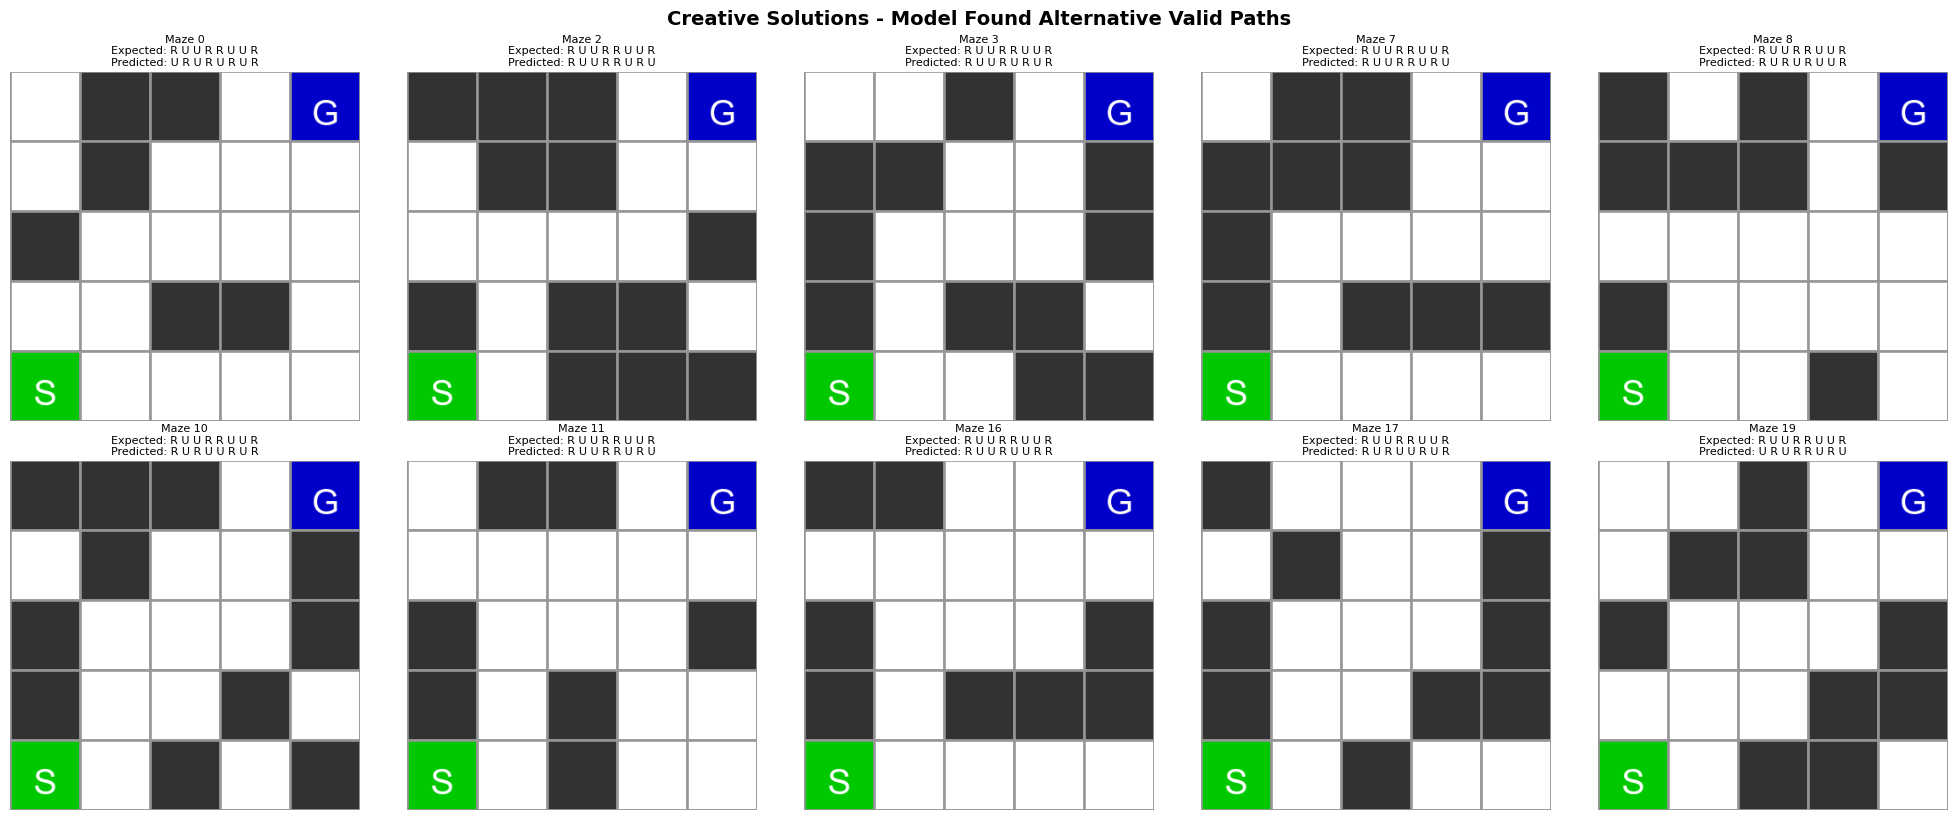

In [57]:
# Show creative solutions (valid but different) WITH IMAGES
print("\n🎨 CREATIVE SOLUTIONS (Valid but different from training):")
print("=" * 70)

num_to_show = min(10, len(creative_solutions))
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, detail in enumerate(creative_solutions[:num_to_show]):
    # Load and display image
    maze_id = detail['maze_id']
    image_path = test_entries[maze_id]['image']
    img = Image.open(image_path)
    
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"Maze {maze_id}\n"
        f"Expected: {' '.join(detail['expected'])}\n"
        f"Predicted: {' '.join(detail['predicted'])}",
        fontsize=8,
        wrap=True
    )
    
    # Print text details
    print(f"\nMaze {maze_id}:")
    print(f"  Expected:  {' '.join(detail['expected'])}")
    print(f"  Predicted: {' '.join(detail['predicted'])}")
    print(f"  Length: Expected={len(detail['expected'])}, Predicted={len(detail['predicted'])}")

plt.tight_layout()
plt.suptitle("Creative Solutions - Model Found Alternative Valid Paths", 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [58]:
# Show failed solutions
print("\n❌ INVALID SOLUTIONS (First 10):")
print("=" * 70)
for i, detail in enumerate(invalid_solutions[:10]):
    val = detail['validation']
    if val:
        reason = "hit wall" if val.get('hit_wall') else \
                 ("out of bounds" if val.get('out_of_bounds') else \
                 ("invalid token" if val.get('invalid_token') else "didn't reach goal"))
        
        print(f"\nMaze {detail['maze_id']}: FAILED - {reason}")
        print(f"  Expected:  {' '.join(detail['expected'])}")
        print(f"  Predicted: {' '.join(detail['predicted'])}")
        print(f"  Final position: {val['final_position']}")
        print(f"  Moves made: {val['num_moves']}")


❌ INVALID SOLUTIONS (First 10):

Maze 1: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R R U U R U U R
  Final position: (2, 4)
  Moves made: 2

Maze 4: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R U U R R U R R
  Final position: (3, 1)
  Moves made: 6

Maze 5: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R U U R R U R U
  Final position: (3, 1)
  Moves made: 6

Maze 6: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R U U R R U R R
  Final position: (3, 1)
  Moves made: 6

Maze 9: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R U U R U U R R
  Final position: (2, 2)
  Moves made: 4

Maze 13: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R U U R R U R R
  Final position: (3, 1)
  Moves made: 6

Maze 14: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R R R U R U U R
  Final position: (3, 3)
  Moves made: 4

Maze 18: FAILED - hit wall
  Expected:  R U U R R U U R
  Predicted: R U U U R U U

## 7. Summary & Next Steps

In [59]:
print("\n" + "=" * 70)
print("SUMMARY & INTERPRETATION")
print("=" * 70)

exact_pct = test_results['exact_match_pct']
valid_pct = test_results['valid_solution_pct']
creative_pct = 100 * len(creative_solutions) / test_results['total']

print(f"\nOriginal metric (exact match):  {exact_pct:.1f}%")
print(f"True performance (valid solns): {valid_pct:.1f}%")
print(f"Creative solutions:             {creative_pct:.1f}%")

improvement = valid_pct - exact_pct
print(f"\n📈 Performance underestimated by: {improvement:.1f}%")

if valid_pct >= 60:
    print("\n✅ EXCELLENT: Model is generalizing well!")
    print("   → Model learned spatial reasoning, not just memorization")
    print("   → High creative solution rate shows true understanding")
    print("   → Consider: Keep current architecture, maybe train longer")
elif valid_pct >= 45:
    print("\n✓ GOOD: Model shows decent generalization")
    print("   → Model has learned some spatial reasoning")
    print("   → Consider: Add more regularization or data augmentation")
else:
    print("\n⚠️  NEEDS WORK: Model struggles with generalization")
    print("   → Model may still be overfitting to training patterns")
    print("   → Consider: Stronger regularization or smaller model")

print("=" * 70)


SUMMARY & INTERPRETATION

Original metric (exact match):  13.1%
True performance (valid solns): 70.1%
Creative solutions:             57.0%

📈 Performance underestimated by: 57.0%

✅ EXCELLENT: Model is generalizing well!
   → Model learned spatial reasoning, not just memorization
   → High creative solution rate shows true understanding
   → Consider: Keep current architecture, maybe train longer


## 8. Save Results to Organized Directory

In [60]:
import os
import json

# Create results directory structure
grid_size = test_metadata['grid_size']
results_dir = f'results/{grid_size}x{grid_size}'
os.makedirs(results_dir, exist_ok=True)

print(f"\n💾 Saving results to: {results_dir}/")
print("="*70)

# 1. Save summary metrics
summary = {
    'timestamp': datetime.now().isoformat(),
    'grid_size': f"{grid_size}×{grid_size}",
    'model_config': {
        'hidden_size': 128,
        'num_layers': 2,
        'num_attention_heads': 2,
        'num_prefix_tokens': 8,
        'dropout': 0.4,
        'total_parameters': sum(p.numel() for p in model.parameters())
    },
    'dataset': {
        'total_test_samples': test_results['total'],
        'unique_solutions': test_metadata.get('unique_solutions', 'N/A'),
        'variations_per_solution': test_metadata.get('variations', 'N/A')
    },
    'performance': {
        'exact_match_pct': test_results['exact_match_pct'],
        'valid_solution_pct': test_results['valid_solution_pct'],
        'creative_solution_pct': creative_pct,
        'invalid_solution_pct': 100 - test_results['valid_solution_pct']
    },
    'breakdown': {
        'exact_matches': len(exact_matches),
        'creative_solutions': len(creative_solutions),
        'invalid_solutions': len(invalid_solutions)
    }
}

# Add training metrics if available in checkpoint
if 'final_loss' in checkpoint:
    summary['training'] = {
        'final_loss': float(checkpoint['final_loss']),
        'train_accuracy': float(checkpoint.get('train_accuracy', 0)),
        'test_accuracy': float(checkpoint.get('test_accuracy', 0)),
        'generalization_gap': float(checkpoint.get('generalization_gap', 0))
    }

# Save summary
summary_path = f'{results_dir}/summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, indent=2, fp=f)
print(f"✓ Saved summary: {summary_path}")

# 2. Save detailed results
detailed_results = {
    'exact_matches': [
        {
            'maze_id': d['maze_id'],
            'expected': d['expected'],
            'predicted': d['predicted']
        }
        for d in exact_matches
    ],
    'creative_solutions': [
        {
            'maze_id': d['maze_id'],
            'expected': d['expected'],
            'predicted': d['predicted'],
            'final_position': d['validation']['final_position'] if d['validation'] else None
        }
        for d in creative_solutions
    ],
    'invalid_solutions': [
        {
            'maze_id': d['maze_id'],
            'expected': d['expected'],
            'predicted': d['predicted'],
            'failure_reason': d['validation'].get('failure_reason', 'unknown') if d['validation'] else 'unknown',
            'final_position': d['validation']['final_position'] if d['validation'] else None
        }
        for d in invalid_solutions
    ]
}

detailed_path = f'{results_dir}/detailed_results.json'
with open(detailed_path, 'w') as f:
    json.dump(detailed_results, indent=2, fp=f)
print(f"✓ Saved detailed results: {detailed_path}")

# 3. Analyze failure modes if any invalid solutions
if invalid_solutions:
    failure_analysis = {
        'total_failures': len(invalid_solutions),
        'failure_types': {}
    }
    
    for detail in invalid_solutions:
        val = detail['validation']
        if val:
            if val.get('hit_wall'):
                reason = 'hit_wall'
            elif val.get('out_of_bounds'):
                reason = 'out_of_bounds'
            elif val.get('invalid_token'):
                reason = 'invalid_token'
            else:
                reason = 'didnt_reach_goal'
            
            failure_analysis['failure_types'][reason] = failure_analysis['failure_types'].get(reason, 0) + 1
    
    failure_path = f'{results_dir}/failure_analysis.json'
    with open(failure_path, 'w') as f:
        json.dump(failure_analysis, indent=2, fp=f)
    print(f"✓ Saved failure analysis: {failure_path}")

# 4. Save a human-readable report
report_lines = [
    f"Maze Solver Results - {grid_size}×{grid_size} Grid",
    "="*70,
    f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f"\nModel Configuration:",
    f"  Architecture: ResNet18 + GPT2 with Prefix-Tuning",
    f"  Hidden size: 128-dim",
    f"  Layers: 2",
    f"  Attention heads: 2",
    f"  Prefix tokens: 8",
    f"  Total parameters: {summary['model_config']['total_parameters']:,}",
    f"\nDataset:",
    f"  Test samples: {test_results['total']}",
    f"  Grid size: {grid_size}×{grid_size}",
    f"\nPerformance Metrics:",
    f"  Exact Match Accuracy:    {test_results['exact_match_pct']:.1f}%",
    f"  Valid Solution Rate:     {test_results['valid_solution_pct']:.1f}%",
    f"  Creative Solutions:      {creative_pct:.1f}%",
    f"  Invalid Solutions:       {100 - test_results['valid_solution_pct']:.1f}%",
    f"\nBreakdown:",
    f"  Exact matches:       {len(exact_matches):4d} ({100*len(exact_matches)/test_results['total']:.1f}%)",
    f"  Creative solutions:  {len(creative_solutions):4d} ({100*len(creative_solutions)/test_results['total']:.1f}%)",
    f"  Invalid solutions:   {len(invalid_solutions):4d} ({100*len(invalid_solutions)/test_results['total']:.1f}%)",
    ""
]

if 'training' in summary:
    report_lines.extend([
        f"\nTraining Metrics:",
        f"  Final loss: {summary['training']['final_loss']:.4f}",
        f"  Train accuracy (exact): {summary['training']['train_accuracy']:.1f}%",
        f"  Test accuracy (exact): {summary['training']['test_accuracy']:.1f}%",
        f"  Generalization gap: {summary['training']['generalization_gap']:.1f}%",
        ""
    ])

if invalid_solutions:
    report_lines.extend([
        f"\nFailure Analysis:",
    ])
    for reason, count in failure_analysis['failure_types'].items():
        report_lines.append(f"  {reason.replace('_', ' ').title()}: {count}")

report_lines.extend([
    "",
    "="*70,
    f"\nInterpretation:",
])

if test_results['valid_solution_pct'] >= 85:
    report_lines.extend([
        "✅ EXCELLENT: Model is generalizing exceptionally well!",
        "   → Model learned spatial reasoning, not memorization",
        "   → High creative solution rate shows true understanding",
        "   → Ready for production or more complex tasks"
    ])
elif test_results['valid_solution_pct'] >= 70:
    report_lines.extend([
        "✅ GOOD: Model shows solid generalization",
        "   → Model learned spatial patterns successfully",
        "   → Room for improvement with more training/data"
    ])
elif test_results['valid_solution_pct'] >= 50:
    report_lines.extend([
        "⚠️  MODERATE: Model is learning but struggling",
        "   → Consider more training epochs or regularization",
        "   → May need architecture adjustments"
    ])
else:
    report_lines.extend([
        "❌ NEEDS WORK: Model struggles with generalization",
        "   → May be overfitting or underfitting",
        "   → Consider architecture changes or more diverse data"
    ])

report_lines.append("="*70)

report_path = f'{results_dir}/report.txt'
with open(report_path, 'w') as f:
    f.write('\n'.join(report_lines))
print(f"✓ Saved report: {report_path}")

print("\n" + "="*70)
print("✅ All results saved successfully!")
print("="*70)
print(f"\nResults location: {results_dir}/")
print("  - summary.json          (metrics overview)")
print("  - detailed_results.json (all predictions)")
print("  - failure_analysis.json (error breakdown)")
print("  - report.txt            (human-readable summary)")
print("="*70)


💾 Saving results to: results/5x5/
✓ Saved summary: results/5x5/summary.json
✓ Saved detailed results: results/5x5/detailed_results.json
✓ Saved failure analysis: results/5x5/failure_analysis.json
✓ Saved report: results/5x5/report.txt

✅ All results saved successfully!

Results location: results/5x5/
  - summary.json          (metrics overview)
  - detailed_results.json (all predictions)
  - failure_analysis.json (error breakdown)
  - report.txt            (human-readable summary)
